Nombre: David Díaz Paz y Puente | Matricula: 650794 | "Doy mi palabra que he realizado esta actividad con integridad académica."

# A2.1 Regresión logística y validación cruzada

## Definición del problema de clasificación

En esta etapa, el problema previamente abordado como regresión se reformula como un problema de clasificación supervisada. La variable de salida será `est_socio`, que representa el estrato socioeconómico del hogar con cuatro categorías ordinales: Bajo (1), Medio bajo (2), Medio alto (3) y Alto (4). Aquí la intención es encontrar un modelo que tome una decisión binaria por cada clase: "¿este hogar es Bajo o no es Bajo?".

A diferencia del modelo anterior, donde se estimaba la variable continua `ing_pc_tri` (ingreso per cápita trimestrial), ahora el objetivo es predecir la probabilidad de que un hogar pertenezca a un determinado estrato socioeconómico a partir de sus características estructurales y condiciones de vivienda. Esta variable es relevante porque sintetiza información multidimensional sobre bienestar y nivel económico de una o más familias por vivienda, permitiendo una interpretación directa en términos de clasificación social. 

Finalmente, también es importante revisar el equilibrio entre las clases, ya que si una categoría concentra una proporción significativamente mayor de observaciones en comparación con las demás, el modelo puede verse inducido a favorecer la elección de la clase mayoritaria al predecir. Esto puede producir desbalance en métricas (como un "alto" *accuracy*), pero con un desempeño deficiente al identificar correctamente las clases minoritarias, lo cual reduce la utilidad del modelo para el análisis socioeconómico.

In [38]:
import pandas as pd 

df = pd.read_csv('features_lasso.csv')


## Separación de datos y balance de clases

Para una comparativa justa, se importó la base de datos generada posterior a su limpieza y a la selección de características mediante la función `LassoCV()`. A partir de aquí procedemos a hacer la partición de datos en entrenamiento y prueba, conservando la proporción de clases entre ambos conjuntos mediante la manipulación de la función `train_test_split()`, específicamente de su parámetro `stratify` el cual podemos manipular de forma que respete la proporción de la variable `y` que asignamos (`est_socio`). 

In [39]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

TARGET   = 'est_socio'
DROP     = [TARGET]   # excluir variable objetivo 
FEATURES = [c for c in df.columns if c not in DROP]

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Total de observaciones : {len(df):>5}")
print(f"Entrenamiento (80 %)   : {len(X_train):>5}")
print(f"Prueba        (20 %)   : {len(X_test):>5}")

Total de observaciones :  3767
Entrenamiento (80 %)   :  3013
Prueba        (20 %)   :   754


Para una mejor apreciación nos apoyaremos de la librería `matplotlib` para graficar las proporciones que resultaron y comparar las particiones con la base de datos original. 

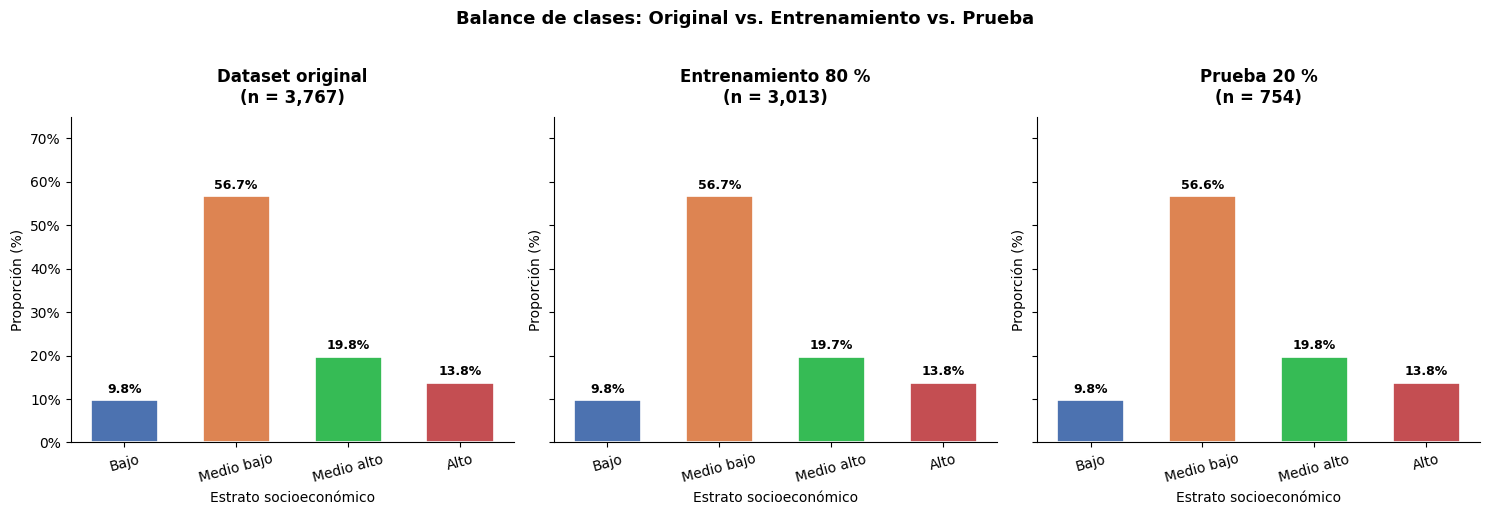

In [40]:
etiquetas = {1: "Bajo", 2: "Medio bajo", 3: "Medio alto", 4: "Alto"}

categorias = [etiquetas[k] for k in sorted(etiquetas)]
colores    = ["#4C72B0", "#DD8452", "#36BB55", "#C44E52"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, (serie, titulo, n) in zip(axes, [
    (y,       "Dataset original",      len(y)),
    (y_train, "Entrenamiento 80 %",    len(y_train)),
    (y_test,  "Prueba 20 %",           len(y_test)),
]):
    pcts = serie.value_counts(normalize=True).sort_index() * 100
    bars = ax.bar(categorias, pcts.values, color=colores,
                  edgecolor="white", linewidth=1.2, width=0.6)
    ax.set_title(f"{titulo}\n(n = {n:,})", fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("Estrato socioeconómico", fontsize=10)
    ax.set_ylabel("Proporción (%)", fontsize=10)
    ax.set_ylim(0, 75)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.tick_params(axis="x", rotation=15)
    ax.spines[["top", "right"]].set_visible(False)
    for bar, val in zip(bars, pcts.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 1,
                f"{val:.1f}%", ha="center", va="bottom",
                fontsize=9, fontweight="bold")

plt.suptitle("Balance de clases: Original vs. Entrenamiento vs. Prueba",
             fontsize=13, y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

La partición estratificada de clases es necesaria para evitar sesgos en la evaluación del modelo que no reflejen la distribución real de los datos. Este problema se manifiesta directamente en métricas como *accuracy* y *F1-score*: si `train_test_split` divide los datos de forma puramente aleatoria, el conjunto de prueba podría contener una proporción desbalanceada de alguna clase, lo que produciría un modelo que sobreestima dicha clase y cuyas métricas de desempeño no son representativas de su comportamiento en datos reales.

## Evaluación mediante validación cruzada

La evaluación fue realizada mediante validación cruzada de K-Pliegues Estratificada (`StratifiedKFold()`). Este método de validación cruzada define como una estrategia de evaluación que divide el conjunto de datos en k subconjuntos (pliegues) de tamaño aproximadamente igual, donde cada división preserva la proporción original de clases presente en el dataset completo. 

En cada iteración, uno de los $k$ pliegues se reserva como conjunto de validación mientras los $k-1$ restantes se utilizan para entrenar el modelo, rotando sistemáticamente hasta que todos los pliegues hayan fungido como validación. El desempeño final del modelo se estima como el promedio de las métricas obtenidas en las $k$ iteraciones.

Adicional a lo anterior y a la función base: `cross_validate()`, la metodología fue complementada con `StandardScaler` (utilizado para normalizar las variables para que cada una tenga media = 0 y desviación estándar = 1) debido a las escalas de las variables de la base de datos, como `estim_pago`. Finalmente la función `Pipeline()` encadena pasos en secuencia y garantiza que el scaler se ajuste únicamente con los datos de entrenamiento de cada pliegue, y solo transforme los de validación.

In [41]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=5000, solver='lbfgs', random_state=42))
])

cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'f1_macro', 'f1_weighted']

cv_results = cross_validate(
    pipe, X_train, y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

metricas = {
    'Accuracy':       ('train_accuracy',              'test_accuracy'),
    'F1-macro':       ('train_f1_macro',               'test_f1_macro'),
    'F1-weighted':    ('train_f1_weighted',             'test_f1_weighted'),
}

rows = []
for nombre, (train_key, test_key) in metricas.items():
    tr = cv_results[train_key]
    te = cv_results[test_key]
    row = {'Métrica': nombre}
    for i, (t, v) in enumerate(zip(tr, te), 1):
        row[f'Train F{i}'] = round(t, 4)
        row[f'Val F{i}']   = round(v, 4)
    row['Train μ']  = round(tr.mean(), 4)
    row['Val μ']    = round(te.mean(), 4)
    row['Val σ']    = round(te.std(),  4)
    rows.append(row)

tabla_cv = pd.DataFrame(rows).set_index('Métrica')
print("Resultados de validación cruzada (5 pliegues estratificados):")
print(tabla_cv.to_string())


Resultados de validación cruzada (5 pliegues estratificados):
             Train F1  Val F1  Train F2  Val F2  Train F3  Val F3  Train F4  Val F4  Train F5  Val F5  Train μ   Val μ   Val σ
Métrica                                                                                                                       
Accuracy       0.7402  0.7148    0.7469  0.7247    0.7427  0.7081    0.7412  0.7342    0.7424  0.7226   0.7427  0.7209  0.0089
F1-macro       0.6753  0.6380    0.6877  0.6525    0.6775  0.6447    0.6805  0.6621    0.6768  0.6653   0.6796  0.6525  0.0103
F1-weighted    0.7282  0.7028    0.7379  0.7078    0.7308  0.6986    0.7309  0.7229    0.7306  0.7156   0.7317  0.7095  0.0088


Las últimas 3 columnas de la salida del snippet anterior resumen todo: 
- Train μ: promedio de los 5 valores de entrenamiento
- Val μ: promedio de los 5 valores de validación (el número que más importa)
- Val σ: qué tan variable fue el desempeño entre pliegues

Para la métrica de _accuracy_ (Val μ = 0.7209, Val σ = 0.0089) podemos concluir que en general el modelo clasifica de forma correcta el estrato socioeconómico de 7 de cada 10 hogares.<br>

Por otro lado, recordando la sección de _Separación de datos y balance de clases_, encontramos 
que la clase _Medio bajo_ describe una gran mayoría de las observaciones (~57%), esto por su 
cuenta garantiza un modelo tendiente a identificar en mayor proporción dicha clase. Si comparamos 
el Val μ = 0.6525 de la métrica de evaluación F1-macro (la cual te dice si el modelo es 
simultáneamente confiable y completo) con el 57% que obtendría un clasificador trivial que 
predijera siempre _Medio bajo_, la mejora real del modelo es de apenas 8% (pp).<br>

Esto confirma que una fracción importante del desempeño observado no proviene del aprendizaje de 
patrones genuinos, sino de la inercia estadística de la clase dominante, lo que limita la 
utilidad del modelo para identificar correctamente los estratos _Bajo_ y _Alto_, que son 
precisamente los de mayor relevancia para el análisis socioeconómico.

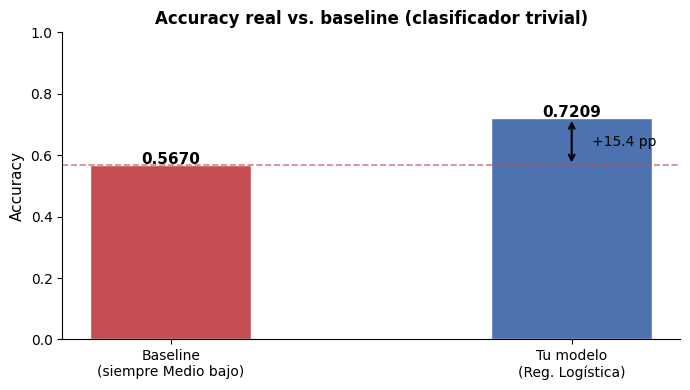

In [42]:
# ── Distribución real de clases ───────────────────────────────────────────────
conteos   = y.value_counts().sort_index()
total     = len(y)

# ── Clase mayoritaria (el modelo más flojo posible) ───────────────────────────
clase_mayoritaria     = conteos.idxmax()
accuracy_baseline     = conteos.max() / total

# ── Comparación contra tu modelo real ────────────────────────────────────────
accuracy_modelo = 0.7209   # Val μ de tu validación cruzada
mejora_real     = accuracy_modelo - accuracy_baseline

# ── Visualización ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

barras = ax.bar(
    ['Baseline\n(siempre Medio bajo)', 'Tu modelo\n(Reg. Logística)'],
    [accuracy_baseline, accuracy_modelo],
    color=['#C44E52', '#4C72B0'],
    width=0.4, edgecolor='white'
)

# Línea de referencia baseline
ax.axhline(accuracy_baseline, color='#C44E52', linestyle='--',
           linewidth=1.2, alpha=0.7)

# Anotación de la mejora real
ax.annotate('',
    xy=(1, accuracy_modelo),
    xytext=(1, accuracy_baseline),
    arrowprops=dict(arrowstyle='<->', color='black', lw=1.5)
)
ax.text(1.05, (accuracy_modelo + accuracy_baseline) / 2,
        f'+{mejora_real*100:.1f} pp', va='center', fontsize=10, color='black')

# Etiquetas sobre las barras
for bar, val in zip(barras, [accuracy_baseline, accuracy_modelo]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')

ax.set_ylim(0, 1)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Accuracy real vs. baseline (clasificador trivial)', fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

Adicionalmente, la desviación estándar entre pliegues (Val σ) aporta una dimensión de 
información que una partición simple no puede ofrecer: la estabilidad del modelo. En este caso, 
los valores de Val σ oscilan entre 0.005 y 0.010 en todas las métricas, lo que indica que el 
desempeño del modelo es consistente independientemente de qué observaciones se utilicen para 
entrenarlo o evaluarlo. Un modelo con alta varianza entre pliegues, por el contrario, sería una 
señal de inestabilidad que ninguna métrica de una sola partición podría detectar.

Por último, la validación cruzada estrtificada en 5 pliegues elimina el error de arbitrariedad, de modo que el promedio de las métricas resultantes no refleja el comportamiento del modelo en una sola partición afortunada o desafortunada. Esta validación es un paso intermedio para confirmar que el modelo aprendió patrones generalizables antes de someterlo a la evaluación definitiva, sin comprometer la integridad del conjunto de prueba que aún no has usado.

## Entrenamiento final y evaluación en prueba

Reporte de Clasificación en el Conjunto de Prueba:
------------------------------------------------------------
              precision    recall  f1-score   support

        Bajo       0.70      0.57      0.63        74
  Medio bajo       0.76      0.85      0.80       427
  Medio alto       0.43      0.37      0.40       149
        Alto       0.70      0.61      0.65       104

    accuracy                           0.69       754
   macro avg       0.65      0.60      0.62       754
weighted avg       0.68      0.69      0.68       754



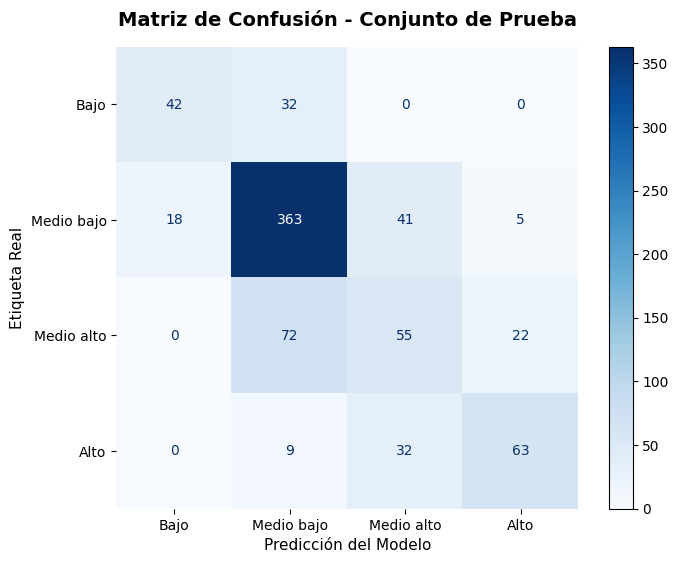

In [43]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Entrenamiento final con todo el conjunto de entrenamiento
pipe.fit(X_train, y_train)

# 2. Predicción sobre el conjunto de prueba
y_pred = pipe.predict(X_test)

# 3. Reporte de clasificación
print("Reporte de Clasificación en el Conjunto de Prueba:")
print("-" * 60)
print(classification_report(y_test, y_pred, target_names=categorias))

# 4. Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=categorias)
disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title("Matriz de Confusión - Conjunto de Prueba", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Predicción del Modelo", fontsize=11)
plt.ylabel("Etiqueta Real", fontsize=11)
ax.spines[['top', 'right', 'bottom', 'left']].set_visible(False)
plt.show()

Dada la matriz de confusión realizada podemos identificar que el modelo es particularmente bueno en predecir correctamente (_true positive_) la clase _Medio baja_, esto se lo podemos atribuir a las distribución de observaciones encontrada desde un inicio la cual daba indicios de un sobreajuste a esta clase. Para otras clases las predicciones realmente no terminaron siendo de lo mejor tomando en cuenta que las proporción de _falsos positivos_ que existen en clases como _Alto_, _Bajo_ y _Medio alto_. En otras palabras, la métrica de accuracy (0.69) es relativamente buena debido a la identificación de la clase _Medio baja_, y esto también lo podemos ver tanto en la f1-score de validación como de entrenamiento (0.6525).

In [44]:
from sklearn.metrics import precision_score, recall_score, f1_score

# 1. Obtener las probabilidades de predicción
# pipe.classes_ contiene las clases ordenadas [1, 2, 3, 4]. El índice 0 corresponde a "Bajo"
y_proba_bajo = pipe.predict_proba(X_test)[:, 0]

# 2. Crear una etiqueta binaria real: 1 si es "Bajo", 0 en caso contrario
y_test_bajo = (y_test == 1).astype(int)

# 3. Evaluar distintos umbrales
umbrales = [0.20, 0.30, 0.40, 0.50, 0.60, 0.80]
resultados_umbrales = []

for umbral in umbrales:
    # Si la probabilidad es mayor o igual al umbral, predecimos 1 ("Bajo")
    y_pred_umbral = (y_proba_bajo >= umbral).astype(int)
    
    precision = precision_score(y_test_bajo, y_pred_umbral, zero_division=0)
    recall = recall_score(y_test_bajo, y_pred_umbral, zero_division=0)
    f1 = f1_score(y_test_bajo, y_pred_umbral, zero_division=0)
    
    resultados_umbrales.append([umbral, round(precision, 4), round(recall, 4), round(f1, 4)])

# 4. Mostrar resultados en un DataFrame
df_umbrales = pd.DataFrame(resultados_umbrales, columns=["Umbral", "Precisión", "Recall (Sensibilidad)", "F1-Score"])

print("Análisis de Umbrales para clasificar la clase 'Bajo' vs 'Resto':")
print("-" * 75)
print(df_umbrales)

Análisis de Umbrales para clasificar la clase 'Bajo' vs 'Resto':
---------------------------------------------------------------------------
   Umbral  Precisión  Recall (Sensibilidad)  F1-Score
0     0.2     0.5078                 0.8784    0.6436
1     0.3     0.5743                 0.7838    0.6629
2     0.4     0.5882                 0.6757    0.6289
3     0.5     0.7000                 0.5676    0.6269
4     0.6     0.7609                 0.4730    0.5833
5     0.8     0.8889                 0.2162    0.3478


El análisis de umbrales revela una regla general de relación inversamente proporcional entre la precisión y la sensibilidad (recall), donde modificar el umbral obliga al modelo a volverse más estricto o más permisivo. Al utilizar umbrales bajos (0.2 y 0.3), se prioriza no dejar a nadie fuera; por ejemplo, con un umbral de 0.2 el modelo identifica casi el 88% de los hogares de estrato Bajo (recall de 0.8784), aunque su precisión cae a cerca del 50%, generando una mayor cantidad de falsos positivos. Curiosamente, el umbral de 0.3 representa el punto de equilibrio matemático al maximizar el F1-Score (0.6629), logrando detectar al 78% de estos hogares vulnerables manteniendo un nivel aceptable del 57% en precisión. Por otro lado, el umbral por defecto de Scikit-Learn (0.5) actúa de manera más conservadora: aunque la precisión sube al 70%, el modelo sacrifica la detección y deja escapar a más del 43% de los hogares que realmente son bajos (recall del 56.7%). Finalmente, si optamos por umbrales altos (0.6 y 0.8) para priorizar la certeza absoluta, el modelo se vuelve extremadamente exigente; con un corte de 0.8, la precisión roza el 89%, pero la consecuencia es catastrófica para la sensibilidad, la cual se desploma a 0.2162. Bajo este criterio tan estricto, el algoritmo ignora a casi el 78% de los hogares de estrato Bajo, hundiendo el F1-score a 0.3478 y resultando en un clasificador fuertemente desequilibrado.

## Curva ROC y AUC

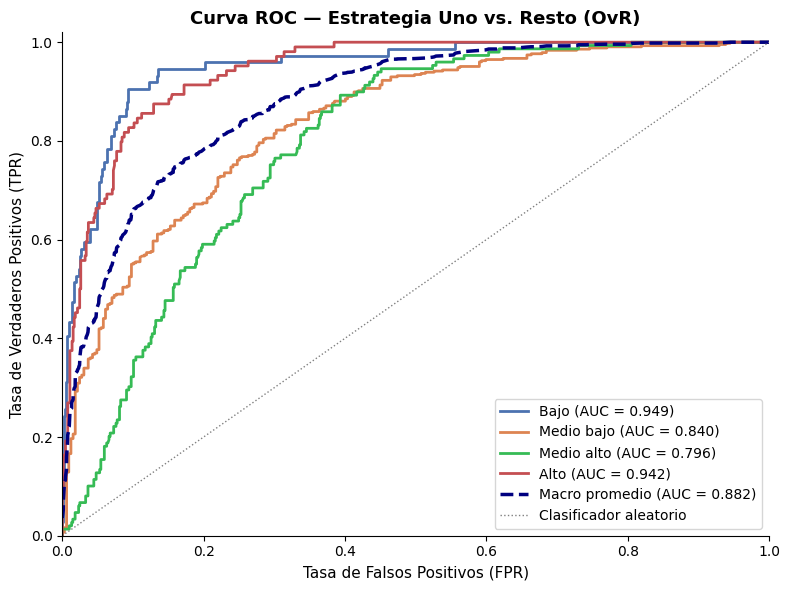

In [ ]:
import pandas as pd

# Extraemos el modelo de tu pipeline
modelo_logistico = pipe[-1]

# Extraemos los nombres de las columnas
try:
    nombres_variables = pipe[:-1].get_feature_names_out()
except:
    nombres_variables = X_train.columns

# Creamos la tabla con los coeficientes
df_coeficientes = pd.DataFrame(
    modelo_logistico.coef_, 
    columns=nombres_variables, 
    index=["Bajo", "Medio bajo", "Medio alto", "Alto"]
)

# Mostramos la tabla en pantalla
display(df_coeficientes)

- Bajo (AUC = 0.9493)<br>
El modelo puede distinguir correctamente los casos “Bajo” frente a las demás categorías en aproximadamente 95% de las comparaciones. Es una de las clases mejor modeladas.

- Alto (AUC = 0.9421)<br>
También muestra un desempeño alto, casi al mismo nivel que “Bajo”. Esto sugiere que los extremos del nivel socioeconómico están bien diferenciados por las variables utilizadas.

- Medio bajo (AUC = 0.8398)<br>
Presenta un desempeño bueno, aunque inferior ante las clases extremas. El modelo logra distinguir esta clase de forma adecuada, pero existe mayor superposición con otras categorías, especialmente con “Medio alto”.

- Medio alto (AUC = 0.7956)<br>
Es la clase con menor capacidad de discriminación. Aunque el resultado sigue siendo aceptable (mayor a 0.7), indica que el modelo tiene más dificultad para separarla del resto, probablemente porque comparte características similares con _Medio bajo_ o incluso con _Alto_.

En general, el modelo es bueno para discriminar las clases extremas (_Bajo_ y _Alto_), prácticamente esto es debido a que las características de las viviendas más pobres y las más ricas suelen ser muy marcadas y distintas al promedio, lo que facilita el trabajo del algoritmo para trazar una frontera de decisión. Por otro lado, las clases medias tienden a traslaparse. Las características de un hogar _Medio alto_ pueden ser extremadamente similares a las de un _Alto_ modesto o a las de un _Medio bajo_ acomodado

- Macro promedio (AUC = 0.8824)<br>
En promedio, el modelo tiene una muy buena capacidad de clasificación global. Un AUC macro cercano a 0.88 indica que, considerando todas las clases por igual, el modelo distingue correctamente las categorías en casi 88% de los casos.

## Interpretación del modelo


In [50]:
import pandas as pd

# 1. Extraemos el modelo de tu pipeline (asumiendo que se llama 'pipe')
modelo_logistico = pipe[-1]

# 2. Extraemos los nombres de las columnas (variables)
try:
    # Intenta obtener nombres si usaste transformadores que los proveen
    nombres_variables = pipe[:-1].get_feature_names_out()
except:
    # Si falla, asume que son las columnas de X_train original
    nombres_variables = X_train.columns

# 3. Creamos la tabla BASE con los coeficientes
df_raw = pd.DataFrame(
    modelo_logistico.coef_, 
    columns=nombres_variables, 
    index=["Bajo", "Medio bajo", "Medio alto", "Alto"]
)

# ── 4. Modificaciones para visibilidad ─────────────────────────────────────

# a) Transponemos la tabla (Variables en filas, Clases en columnas)
df_visible = df_raw.T

# b) Aplicamos Estilo Condicional: Gradiente de color y formato numérico
#    - 'coolwarm': Azul es negativo, Rojo es positivo, Blanco es cero.
#    - axis=None: El gradiente se calcula considerando TODO el DataFrame, no por columna.
tabla_estilizada = df_visible.style.background_gradient(cmap='coolwarm', axis=None) \
                                   .format("{:.4f}")

# 5. Mostramos la tabla final
display(tabla_estilizada)

,Bajo,Medio bajo,Medio alto,Alto
cocina,0.0491,0.0038,-0.0434,-0.0095
cocina_dor,-0.0780,-0.0044,0.0045,0.0779
num_cuarto,0.2656,-0.2029,0.0215,-0.0843
bano_comp,-0.0012,-0.0121,-0.3245,0.3378
bano_excus,-0.0188,-0.2530,-0.1728,0.4447
bano_regad,-0.1613,0.1414,0.0606,-0.0407
estim_pago,-1.5210,-0.5802,0.5578,1.5434
tot_resid,0.1419,0.1101,-0.0445,-0.2076
tipo_viv_4,-0.1831,-0.0037,0.0292,0.1576
mat_pared_7,-0.4404,-0.0369,0.6665,-0.1892


En el modelo de regresión logística multinomial, los coeficientes permiten analizar cómo cada variable influye en la probabilidad de pertenecer a cada nivel socioeconómico. En términos generales, se observa que las variables relacionadas con infraestructura básica y servicios del hogar (como drenaje, tipo de excusado y eliminación de basura) presentan coeficientes positivos importantes en la clase _Bajo_ y negativos en las clases _Medio alto_ y _Alto_, lo cual indica que la presencia de carencias incrementa la probabilidad de pertenecer al nivel socioeconómico más bajo y disminuye la probabilidad de pertenecer a niveles superiores. Por otro lado, la variable ``estim_pago`` muestra el efecto más fuerte del modelo: tiene un coeficiente negativo elevado en la clase _Bajo_ y un coeficiente positivo muy alto en la clase _Alto_, lo que sugiere que una mayor capacidad económica reduce significativamente la probabilidad de estar en nivel bajo y aumenta de manera considerable la probabilidad de estar en nivel alto. Asimismo, variables relacionadas con materiales de vivienda (paredes, pisos y techos) tienden a tener efectos positivos en _Medio alto_ y _Alto_, reflejando que mejores condiciones estructurales están asociadas con mayor nivel socioeconómico. En términos de magnitud relativa, los coeficientes más grandes corresponden precisamente a variables económicas y de servicios básicos, lo cual es coherente con la problemática original, ya que el nivel socioeconómico está directamente vinculado con el acceso a recursos y calidad de vivienda. En conjunto, los resultados muestran consistencia teórica y permiten concluir que el modelo no solo tiene capacidad predictiva, sino también interpretabilidad alineada con la realidad social que se está estudiando.